# Coastal Erosion Forecasting System

This notebook contains the **complete, self-contained** pipeline for:
1. Loading shoreline data from KML files
2. Processing shorelines into transects
3. Training a Linear Regression model for each transect
4. Forecasting future shoreline positions
5. Generating visualizations and statistics

**No external `.py` files are required.**

## 1. Dependencies & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from datetime import datetime, timedelta
import xml.etree.ElementTree as ET
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist

%matplotlib inline

# Configuration - these defaults are overridden by Papermill when run from the backend
KML_DIR = os.path.join(os.getcwd(), "data", "high_res_kml")
OUTPUT_DIR = os.path.join(os.getcwd(), "output")
DATA_DIR = os.path.join(os.getcwd(), "data")
TARGET_YEAR = 2029
MODEL_TYPE = "Ensemble"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


In [2]:
# Parameters
TARGET_YEAR = 2031
MODEL_TYPE = "LinearRegression"
KML_DIR = "C:\\Users\\Tharu\\OneDrive\\Documents\\GitHub\\coastalai\\data\\high_res_kml"
OUTPUT_DIR = "C:\\Users\\Tharu\\OneDrive\\Documents\\GitHub\\coastalai\\output"
DATA_DIR = "C:\\Users\\Tharu\\OneDrive\\Documents\\GitHub\\coastalai\\data"


## 2. Extract Shoreline (src/extract_shoreline.py)
Extracts shoreline coordinates from images/KML.

In [3]:
import xml.etree.ElementTree as ET
import numpy as np
import os
import re

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print("Warning: OpenCV (cv2) not installed. Image-based shoreline extraction will be unavailable.")
    print("This is OK if you are only using KML files with LineString data.")

def parse_kml_namespace(root):
    """Utility to handle KML namespaces."""
    m = re.match(r'\{.*\}', root.tag)
    return m.group(0) if m else ''

def extract_shoreline_from_image(image_path):
    """
    Uses OpenCV to find the boundary between water and land in an aerial image.
    This uses a basic thresholding approach (which may require tuning based on the image).
    """
    if not HAS_CV2:
        print("Error: OpenCV (cv2) is required for image-based extraction. Install with: pip install opencv-python")
        return None

    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image at {image_path}")
        return None

    # 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Thresholding / Segmentation (Water is typically darker than sand/land)
    # Using Otsu's method to automatically find an optimal threshold line
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. Find contours (boundaries of the shapes)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # 4. Assume the shoreline is the longest continuous contour
    longest_contour = max(contours, key=cv2.contourArea)
    
    # Optional: approximate the contour to smooth the line
    epsilon = 0.002 * cv2.arcLength(longest_contour, True)
    approx_contour = cv2.approxPolyDP(longest_contour, epsilon, False)

    # Return shape info as well for mapping pixels back to coordinates
    height, width = img.shape[:2]
    return approx_contour, width, height

def kml_image_to_linestring(input_kml_path, output_kml_path):
    """
    1. Reads a KML with a GroundOverlay (Image).
    2. Detects the shoreline pixels in the image.
    3. Maps those pixels to Geo-Coordinates (Lat/Lon).
    4. Saves the result as a LineString KML.
    """
    if not os.path.exists(input_kml_path):
        print(f"File not found: {input_kml_path}")
        return False

    tree = ET.parse(input_kml_path)
    root = tree.getroot()
    ns = parse_kml_namespace(root)

    # Extract Bounding Box and Image Path from GroundOverlay
    ground_overlay = root.find(f'.//{ns}GroundOverlay')
    if ground_overlay is None:
        print("No <GroundOverlay> found in KML. We need an image overlay to extract a shoreline from.")
        return False

    icon = ground_overlay.find(f'{ns}Icon')
    latlonbox = ground_overlay.find(f'{ns}LatLonBox')

    if icon is None or latlonbox is None:
        print("Missing <Icon> (image path) or <LatLonBox> (coordinates) in GroundOverlay.")
        return False

    img_href = icon.find(f'{ns}href').text
    
    # Resolve relative image paths
    if not os.path.isabs(img_href):
        img_href = os.path.join(os.path.dirname(input_kml_path), img_href)

    north = float(latlonbox.find(f'{ns}north').text)
    south = float(latlonbox.find(f'{ns}south').text)
    east = float(latlonbox.find(f'{ns}east').text)
    west = float(latlonbox.find(f'{ns}west').text)

    print(f"Reading image overlay: {img_href}")
    result = extract_shoreline_from_image(img_href)
    if not result:
        print("Failed to detect shoreline in the image.")
        return False

    contour_pixels, img_w, img_h = result

    # Map Pixel Coordinates to Geographic Coordinates (Lon, Lat)
    geo_coords = []
    for point in contour_pixels:
        x, y = point[0] # Pixel [X, Y]
        
        # Linear interpolation
        # X maps to Longitude (West -> East)
        lon = west + (x / img_w) * (east - west)
        # Y maps to Latitude (North -> South, y=0 is top in OpenCV)
        lat = north - (y / img_h) * (north - south)
        
        geo_coords.append(f"{lon:.14f},{lat:.14f},0")

    coord_str = " ".join(geo_coords)

    # Build Output KML with LineString
    filename = os.path.basename(input_kml_path)
    
    kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
	<name>Extracted_{filename}</name>
	<Style id="extracted_line">
		<LineStyle>
			<color>ff0000ff</color>  <!-- Red Line -->
			<width>4</width>
		</LineStyle>
	</Style>
	<Placemark>
		<name>Extracted Shoreline</name>
		<styleUrl>#extracted_line</styleUrl>
		<LineString>
			<tessellate>1</tessellate>
			<coordinates>
				{coord_str}
			</coordinates>
		</LineString>
	</Placemark>
</Document>
</kml>
"""

    with open(output_kml_path, 'w') as f:
        f.write(kml_content)

    print(f"Successfully extracted shoreline saved to: {output_kml_path}")
    return True

This is OK if you are only using KML files with LineString data.


## 3. Data Loading Functions (src/data_loader.py)
Parses KML files and extracts shoreline coordinates.

In [4]:
import os
import re
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import datetime
import glob

def parse_kml_date(filename):
    """
    Extracts date from filename like 'SWnew MMDDYYYY.kml'.
    Example: 'SWnew 10222010.kml' -> datetime(2010, 10, 22)
    """
    match = re.search(r'(\d{1,2})(\d{2})(\d{4})', filename)
    if match:
        month, day, year = match.groups()
        return datetime(int(year), int(month), int(day))
    return None

def read_kml_shoreline(filepath):
    """
    Parses a KML file and returns a list of (lon, lat) tuples.
    """
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        coordinates = []
        for elem in root.iter():
            if 'coordinates' in elem.tag:
                text = elem.text.strip()
                coords_list = text.split()
                for coord in coords_list:
                    parts = coord.split(',')
                    if len(parts) >= 2:
                        lon = float(parts[0])
                        lat = float(parts[1])
                        coordinates.append([lon, lat])
                if coordinates:
                    break
        return coordinates
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return []

def load_all_shorelines(kml_dir):
    """
    Loads all KML files from the directory.
    Returns a dataframe with ['Date', 'Coordinates'].
    """
    files = glob.glob(os.path.join(kml_dir, "*.kml"))
    data = []
    
    for f in files:
        filename = os.path.basename(f)
        date_obj = parse_kml_date(filename)
        if date_obj:
            coords = read_kml_shoreline(f)
            if coords:
                data.append({'Date': date_obj, 'Coordinates': coords})
        else:
            # Try alternative pattern if needed, or just report
            # print(f"Skipping {filename}: Could not parse date")
            pass
            
    df = pd.DataFrame(data)
    if not df.empty:
        df = df.sort_values('Date').reset_index(drop=True)
    return df

def load_transect_stats(csv_path):
    """
    Loads the new transect-based statistics (CSV).
    """
    try:
        df = pd.read_csv(csv_path)
        return df
    except Exception as e:
        print(f"Error loading stats CSV: {e}")
        return pd.DataFrame()



## 4. Preprocessing Functions (src/preprocessing.py)
Creates a baseline, generates transects, and calculates intersection distances.

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist

def create_baseline(all_coords):
    """
    Fits a straight line to all shoreline points to serve as a baseline.
    Returns (slope, intercept, orientation, min_dim, max_dim).
    Note: lat is Y, lon is X. We treat Longitude as function of Latitude for vertical-ish coastlines,
    or Latitude as function of Longitude for horizontal-ish.
    Kalmunai is roughly North-South, so we fit Lon = m * Lat + c
    """
    # Flatten all coordinates
    all_points = np.vstack(all_coords)
    X_lon = all_points[:, 0]
    y_lat = all_points[:, 1]
    
    # Check orientation: variance in Lat vs Lon
    # If var(Lat) > var(Lon), it's North-South (Kalmunai). fit Lon = f(Lat)
    if np.var(y_lat) > np.var(X_lon):
        # Fit Lon = m*Lat + c
        reg = LinearRegression().fit(y_lat.reshape(-1, 1), X_lon)
        slope = reg.coef_[0]
        intercept = reg.intercept_
        orientation = 'NS' # North-South
        min_dim = y_lat.min()
        max_dim = y_lat.max()
    else:
        # Fit Lat = m*Lon + c
        reg = LinearRegression().fit(X_lon.reshape(-1, 1), y_lat)
        slope = reg.coef_[0]
        intercept = reg.intercept_
        orientation = 'EW' # East-West
        min_dim = X_lon.min()
        max_dim = X_lon.max()

    return slope, intercept, orientation, min_dim, max_dim

def generate_transects(slope, intercept, orientation, min_dim, max_dim, num_transects=50):
    """
    Generates transect lines perpendicular to the baseline.
    Returns a list of transects, each defined by a point on the baseline and a direction vector.
    """
    # Generate points along the baseline
    dim_values = np.linspace(min_dim, max_dim, num_transects)
    
    transects = []
    
    if orientation == 'NS':
        # Baseline: Lon = slope * Lat + intercept
        # Vector along baseline: (slope, 1)  [dLon, dLat]
        # Normal vector (perpendicular): (1, -slope) or (-1, slope)
        
        # Let's normalize the normal vector
        normal_vec = np.array([1, -slope])
        normal_vec = normal_vec / np.linalg.norm(normal_vec)
        
        for lat in dim_values:
            lon_base = slope * lat + intercept
            origin = np.array([lon_base, lat])
            transects.append({'origin': origin, 'vector': normal_vec})
            
    else: # EW
        # Baseline: Lat = slope * Lon + intercept
        # Vector along baseline: (1, slope)
        # Normal vector: (-slope, 1)
        
        normal_vec = np.array([-slope, 1])
        normal_vec = normal_vec / np.linalg.norm(normal_vec)
        
        for lon in dim_values:
            lat_base = slope * lon + intercept
            origin = np.array([lon, lat_base])
            transects.append({'origin': origin, 'vector': normal_vec})
            
    return transects

def get_intersection_distance(transect, shoreline_coords):
    """
    Finds the intersection of a transect line with the shoreline.
    Returns distance from baseline along the transect normal.
    Simple method: Find the shoreline point closest to the transect line.
    """
    origin = transect['origin']
    vec = transect['vector']
    
    shoreline_arr = np.array(shoreline_coords)
    
    # Calculate distance of each shoreline point to the transect LINE
    # Line defined by P = origin + t * vec
    # Distance to line = |cross(vec, point-origin)| / |vec|  (|vec| is 1)
    
    d_vecs = shoreline_arr - origin
    
    # Cross product in 2D: vx*dy - vy*dx
    cross_products = vec[0] * d_vecs[:, 1] - vec[1] * d_vecs[:, 0]
    
    # Filter points very close to the line (within some epsilon)
    # Epsilon depends on data scale. decimal degrees. 1e-4 is ~10m.
    mask = np.abs(cross_products) < 1e-4 
    
    candidates = shoreline_arr[mask]
    
    if len(candidates) == 0:
        # Fallback: just find closest point
        closest_idx = np.argmin(np.abs(cross_products))
        candidates = shoreline_arr[closest_idx:closest_idx+1]
        
    # Now find the distance along the vector for these candidates
    candidate_d_vecs = candidates - origin
    distances = candidate_d_vecs[:, 0] * vec[0] + candidate_d_vecs[:, 1] * vec[1]
    
    # If multiple, take average position
    return np.mean(distances)

def process_shorelines(df_shorelines, num_transects=50):
    """
    Main processing function.
    1. Create baseline.
    2. Cast transects.
    3. Calculate distances for each date.
    """
    # 1. Fit global baseline
    all_coords = df_shorelines['Coordinates'].tolist()
    slope, intercept, orient, min_d, max_d = create_baseline(all_coords)
    
    print(f"Baseline fitted. Orientation: {orient}, Slope: {slope:.4f}")
    
    # 2. Generate transects
    transects = generate_transects(slope, intercept, orient, min_d, max_d, num_transects)
    
    # 3. Calculate distances
    results = []
    
    for _, row in df_shorelines.iterrows():
        date = row['Date']
        coords = row['Coordinates']
        
        row_data = {'Date': date}
        for i, tr in enumerate(transects):
            dist = get_intersection_distance(tr, coords)
            row_data[f'Transect_{i}'] = dist
            
        results.append(row_data)
        
    return pd.DataFrame(results)

## 5. Calculate Change (src/calculate_change.py)
Computes change rates (EPR, LRR) from intersections.

In [6]:
import pandas as pd
import numpy as np
import os

def calculate_change():
    history_path = os.path.join(OUTPUT_DIR, "processed_data_full.csv")
    forecast_path = os.path.join(OUTPUT_DIR, "forecast_5_years.csv")
    
    print("Loading data...")
    history_df = pd.read_csv(history_path)
    forecast_df = pd.read_csv(forecast_path)
    
    # Identify Transect columns
    transect_cols = [c for c in history_df.columns if c.startswith('Transect_')]
    
    # Get latest historical row
    history_df['Date'] = pd.to_datetime(history_df['Date'])
    forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])
    
    latest_hist = history_df.sort_values('Date').iloc[-1]
    latest_date = latest_hist['Date']
    print(f"Latest Historical Date: {latest_date.date()}")
    
    # Get final forecast row (5 years out)
    final_forecast = forecast_df.sort_values('Date').iloc[-1]
    forecast_date = final_forecast['Date']
    print(f"Forecast Date: {forecast_date.date()}")
    
    # Calculate difference in DEGREES
    diff_degrees = final_forecast[transect_cols] - latest_hist[transect_cols]
    
    # Convert to Meters (approx 1 degree ~ 111 km)
    METERS_PER_DEG = 111000.0 
    diff_meters = diff_degrees * METERS_PER_DEG
    
    # Stats
    avg_change_m = diff_meters.mean()
    max_accretion_m = diff_meters.max()
    max_erosion_m = diff_meters.min()
    abs_change_m = diff_meters.abs().mean()
    
    print("\n--- Shoreline Change Analysis (5 Years) ---")
    print(f"Average Shift: {avg_change_m:.2f} meters")
    print(f"Mean Absolute Change: {abs_change_m:.2f} meters")
    print(f"Max Possible Accretion (Shift +): {max_accretion_m:.2f} meters")
    print(f"Max Possible Erosion (Shift -): {max_erosion_m:.2f} meters")
    
    # Save per-transect details
    change_df = pd.DataFrame({
        'Transect': transect_cols,
        'Change_Degrees': diff_degrees,
        'Change_Meters': diff_meters
    })
    output_file = os.path.join(OUTPUT_DIR, "shoreline_change_meters.csv")
    change_df.to_csv(output_file, index=False)
    print(f"\nDetailed change per transect saved to: {output_file}")

## 6. Forecasting Functions (src/forecasting.py)
Trains Linear Regression models and predicts future shoreline positions.

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy import stats
from datetime import datetime, timedelta

def prepare_features(df):
    """
    Converts Date to ordinal for regression.
    """
    if 'Date' in df.columns:
        df = df.sort_values('Date')
        base_date = df['Date'].min()
        df['Days'] = (df['Date'] - base_date).dt.days
        return df, base_date
    return df, None

def train_and_predict(df, transect_cols, years_ahead=5, model_type='LinearRegression'):
    """
    Trains model(s) for each transect and forecasts future position.
    
    model_type options:
      - 'LinearRegression' : Standard Linear Regression (original)
      - 'WeightedLR'       : Weighted Linear Regression (recent data weighted higher)
      - 'Polynomial_2'     : Polynomial Regression (degree 2)
      - 'Ridge'            : Ridge Regression (regularized)
      - 'Ensemble'         : Average of all 4 models
    """
    df_processed, base_date = prepare_features(df)
    
    # Define future target dates
    last_date = df_processed['Date'].max()
    future_dates = []
    for i in range(1, years_ahead + 1):
        future_dates.append(last_date + timedelta(days=365 * i))
    
    future_days = [(d - base_date).days for d in future_dates]
    X_future = np.array(future_days).reshape(-1, 1)
    
    X = df_processed[['Days']].values
    n_samples = len(X)
    
    # Weights for Weighted LR
    sample_weights = np.linspace(0.3, 1.0, n_samples)
    
    predictions = {}
    models = {}
    
    print(f"Training model: {model_type} for {len(transect_cols)} transects...")
    
    for col in transect_cols:
        y = df_processed[col].values
        mask = ~np.isnan(y)
        
        if np.sum(mask) < 2:
            predictions[col] = [np.nan] * len(future_dates)
            continue
        
        X_clean = X[mask]
        y_clean = y[mask]
        w_clean = sample_weights[mask]
        
        if model_type == 'Ensemble':
            # Train all models and average
            all_preds = []
            col_models = {}
            
            try:
                m1 = LinearRegression()
                m1.fit(X_clean, y_clean)
                all_preds.append(m1.predict(X_future))
                col_models['LinearRegression'] = m1
            except Exception:
                pass
            
            try:
                m2 = LinearRegression()
                m2.fit(X_clean, y_clean, sample_weight=w_clean)
                all_preds.append(m2.predict(X_future))
                col_models['WeightedLR'] = m2
            except Exception:
                pass
            
            if np.sum(mask) >= 3:
                try:
                    m3 = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))
                    m3.fit(X_clean, y_clean)
                    all_preds.append(m3.predict(X_future))
                    col_models['Polynomial_2'] = m3
                except Exception:
                    pass
            
            try:
                m4 = Ridge(alpha=1.0)
                m4.fit(X_clean, y_clean)
                all_preds.append(m4.predict(X_future))
                col_models['Ridge'] = m4
            except Exception:
                pass
            
            if all_preds:
                predictions[col] = np.mean(all_preds, axis=0)
                models[col] = col_models
            else:
                predictions[col] = [np.nan] * len(future_dates)
        
        else:
            # Train single model
            try:
                if model_type == 'LinearRegression':
                    model = LinearRegression()
                    model.fit(X_clean, y_clean)
                elif model_type == 'WeightedLR':
                    model = LinearRegression()
                    model.fit(X_clean, y_clean, sample_weight=w_clean)
                elif model_type == 'Polynomial_2':
                    if np.sum(mask) < 3:
                        # Fallback to LR if not enough points
                        model = LinearRegression()
                        model.fit(X_clean, y_clean)
                    else:
                        model = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))
                        model.fit(X_clean, y_clean)
                elif model_type == 'Ridge':
                    model = Ridge(alpha=1.0)
                    model.fit(X_clean, y_clean)
                else:
                    # Default to Linear Regression
                    model = LinearRegression()
                    model.fit(X_clean, y_clean)
                
                preds = model.predict(X_future)
                predictions[col] = preds
                models[col] = {model_type: model}
            except Exception:
                predictions[col] = [np.nan] * len(future_dates)
    
    # Construct result DataFrame
    future_df = pd.DataFrame({'Date': future_dates})
    for col, preds in predictions.items():
        future_df[col] = preds
    
    print(f"  Prediction complete using: {model_type}")
    
    return future_df, models

## 7. Evaluate Model (src/evaluate_model.py)
Calculates evaluation metrics (RMSE, MAE, R2).

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

def evaluate_model():
    print("=" * 65)
    print("   Model Evaluation — Comparing All Models (Hindcasting)")
    print("=" * 65)
    
    # Load processed data (distances)
    input_path = os.path.join(OUTPUT_DIR, "processed_data_full.csv")
    if not os.path.exists(input_path):
        print(f"Error: {input_path} not found. Run the processing step first.")
        return
        
    df = pd.read_csv(input_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    # Define Split — use the last 20% of dates as the Test Set
    dates = df['Date'].unique()
    split_idx = int(len(dates) * 0.8)
    split_date = dates[split_idx]
    
    print(f"Total Dates: {len(dates)}")
    print(f"Train/Test Split at: {split_date}")
    
    train_df = df[df['Date'] < split_date].copy()
    test_df = df[df['Date'] >= split_date].copy()
    
    print(f"Train Set: {len(train_df)} rows | Test Set: {len(test_df)} rows")
    
    # Prepare transects
    transect_cols = [c for c in df.columns if c.startswith('Transect_')]
    
    # Define models to compare
    model_names = ['LinearRegression', 'WeightedLR', 'Polynomial_2', 'Ridge', 'Ensemble']
    
    # Storage: model_name -> list of (y_true, y_pred) pairs
    model_results = {name: {'y_true': [], 'y_pred': []} for name in model_names}
    transect_metrics = []
    
    n_train = len(train_df)
    sample_weights = np.linspace(0.3, 1.0, n_train)
    
    print(f"\nEvaluating {len(model_names)} models across {len(transect_cols)} transects...")
    
    # Train & Predict for each transect
    for col in transect_cols:
        base_date = train_df['Date'].min()
        
        y_train = train_df[col].values
        X_train = (train_df['Date'] - base_date).dt.days.values.reshape(-1, 1)
        
        y_test = test_df[col].values
        X_test = (test_df['Date'] - base_date).dt.days.values.reshape(-1, 1)
        
        # Clean NaNs
        mask_train = ~np.isnan(y_train)
        mask_test = ~np.isnan(y_test)
        
        if np.sum(mask_train) < 2 or np.sum(mask_test) < 1:
            continue
        
        X_tr = X_train[mask_train]
        y_tr = y_train[mask_train]
        w_tr = sample_weights[mask_train]
        X_te = X_test[mask_test]
        y_te = y_test[mask_test]
        
        preds_per_model = {}
        
        # --- Model 1: Standard Linear Regression ---
        try:
            m1 = LinearRegression()
            m1.fit(X_tr, y_tr)
            p1 = m1.predict(X_te)
            preds_per_model['LinearRegression'] = p1
        except Exception:
            pass
        
        # --- Model 2: Weighted Linear Regression ---
        try:
            m2 = LinearRegression()
            m2.fit(X_tr, y_tr, sample_weight=w_tr)
            p2 = m2.predict(X_te)
            preds_per_model['WeightedLR'] = p2
        except Exception:
            pass
        
        # --- Model 3: Polynomial Regression (degree 2) ---
        if np.sum(mask_train) >= 3:
            try:
                m3 = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))
                m3.fit(X_tr, y_tr)
                p3 = m3.predict(X_te)
                preds_per_model['Polynomial_2'] = p3
            except Exception:
                pass
        
        # --- Model 4: Ridge Regression ---
        try:
            m4 = Ridge(alpha=1.0)
            m4.fit(X_tr, y_tr)
            p4 = m4.predict(X_te)
            preds_per_model['Ridge'] = p4
        except Exception:
            pass
        
        # --- Ensemble: Average of all available models ---
        if preds_per_model:
            ensemble_pred = np.mean(list(preds_per_model.values()), axis=0)
            preds_per_model['Ensemble'] = ensemble_pred
        
        # Store results for each model
        for name, preds in preds_per_model.items():
            model_results[name]['y_true'].extend(y_te)
            model_results[name]['y_pred'].extend(preds)
        
        # Per-transect metrics (for LR only, for backward compatibility)
        if 'LinearRegression' in preds_per_model:
            rmse = np.sqrt(mean_squared_error(y_te, preds_per_model['LinearRegression']))
            mae = mean_absolute_error(y_te, preds_per_model['LinearRegression'])
            transect_metrics.append({
                'Transect': col,
                'RMSE_deg': rmse,
                'MAE_deg': mae,
                'RMSE_m': rmse * 111000,
                'MAE_m': mae * 111000
            })
    
    # --- Print Comparison Table ---
    METERS_PER_DEG = 111000
    TOLERANCE_5M = 5.0    # meters
    TOLERANCE_10M = 10.0  # meters
    
    print("\n" + "=" * 75)
    print("   MODEL COMPARISON RESULTS")
    print("=" * 75)
    print(f"{'Model':<20} {'Acc(±5m)':>10} {'Acc(±10m)':>10} {'R²':>10} {'RMSE(m)':>10} {'MAE(m)':>10}")
    print("-" * 75)
    
    best_r2 = -999
    best_model = ''
    comparison_rows = []
    
    for name in model_names:
        y_true = np.array(model_results[name]['y_true'])
        y_pred = np.array(model_results[name]['y_pred'])
        
        if len(y_true) < 2:
            print(f"{name:<20} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
            continue
        
        rmse_deg = np.sqrt(mean_squared_error(y_true, y_pred))
        mae_deg = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        rmse_m = rmse_deg * METERS_PER_DEG
        mae_m = mae_deg * METERS_PER_DEG
        
        # Tolerance-based accuracy: % of predictions within ±Xm of actual
        errors_m = np.abs(y_true - y_pred) * METERS_PER_DEG
        acc_5m = np.mean(errors_m <= TOLERANCE_5M) * 100
        acc_10m = np.mean(errors_m <= TOLERANCE_10M) * 100
        
        # Track best model
        if r2 > best_r2:
            best_r2 = r2
            best_model = name
        
        print(f"{name:<20} {acc_5m:>9.1f}% {acc_10m:>9.1f}% {r2:>10.4f} {rmse_m:>10.2f} {mae_m:>10.2f}")
        
        comparison_rows.append({
            'Model': name,
            'Accuracy_5m_%': round(acc_5m, 2),
            'Accuracy_10m_%': round(acc_10m, 2),
            'R2': round(r2, 4),
            'RMSE_m': round(rmse_m, 2),
            'MAE_m': round(mae_m, 2)
        })
    
    print("-" * 75)
    print(f"  >>> BEST MODEL: {best_model} (R² = {best_r2:.4f})")
    print("=" * 75)
    print("\n  Acc(±5m)  = % of predictions within 5 meters of actual")
    print("  Acc(±10m) = % of predictions within 10 meters of actual")
    
    # Save comparison
    comp_df = pd.DataFrame(comparison_rows)
    comp_file = os.path.join(OUTPUT_DIR, "model_comparison.csv")
    comp_df.to_csv(comp_file, index=False)
    print(f"\nModel comparison saved to: {comp_file}")
    
    # Save per-transect metrics (LR)
    metrics_df = pd.DataFrame(transect_metrics)
    out_file = os.path.join(OUTPUT_DIR, "model_accuracy_report.csv")
    metrics_df.to_csv(out_file, index=False)
    print(f"Per-transect LR metrics saved to: {out_file}")
    
    # Save global metrics
    if comparison_rows:
        best_row = [r for r in comparison_rows if r['Model'] == best_model][0]
        metrics_file = os.path.join(OUTPUT_DIR, "global_metrics.txt")
        with open(metrics_file, "w") as f:
            f.write(f"Best Model: {best_model}\n")
            f.write(f"Accuracy (±5m): {best_row['Accuracy_5m_%']:.2f}%\n")
            f.write(f"Accuracy (±10m): {best_row['Accuracy_10m_%']:.2f}%\n")
            f.write(f"R2: {best_row['R2']:.4f}\n")
            f.write(f"RMSE: {best_row['RMSE_m']:.2f} meters\n")
            f.write(f"MAE: {best_row['MAE_m']:.2f} meters\n")
    
    return best_model

## 8. Calculate Forecast Stats (src/calculate_forecast_stats.py)
Generates stats for forecasted shorelines.

In [9]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression

def calculate_stats():
    history_path = os.path.join(OUTPUT_DIR, "processed_data_full.csv")
    forecast_path = os.path.join(OUTPUT_DIR, "forecast_5_years.csv")
    
    # Load Data
    hist_df = pd.read_csv(history_path)
    fore_df = pd.read_csv(forecast_path)
    
    # Ensure Dates
    hist_df['Date'] = pd.to_datetime(hist_df['Date'])
    fore_df['Date'] = pd.to_datetime(fore_df['Date'])
    
    # Transect Columns
    transect_cols = [c for c in hist_df.columns if c.startswith('Transect_')]
    
    stats_rows = []
    
    for col in transect_cols:
        # Combine series
        ts_hist = hist_df[['Date', col]].dropna()
        ts_fore = fore_df[['Date', col]].dropna()
        
        combined = pd.concat([ts_hist, ts_fore]).sort_values('Date')
        
        if combined.empty:
            continue
            
        distances = combined[col].values
        dates = combined['Date'].values
        
        # 1. SCE (Shoreline Change Envelope): Max - Min distance
        sce = np.max(distances) - np.min(distances)
        
        # 2. NSM (Net Shoreline Movement): Newest - Oldest
        nsm = distances[-1] - distances[0]
        
        # 3. EPR (End Point Rate): NSM / Time (years)
        time_span_days = (dates[-1] - dates[0]).astype('timedelta64[D]').astype(int)
        time_span_years = time_span_days / 365.25
        
        if time_span_years > 0:
            epr = nsm / time_span_years
        else:
            epr = 0
            
        # 4. LRR (Linear Regression Rate)
        start_date = dates[0]
        days_from_start = (dates - start_date).astype('timedelta64[D]').astype(int)
        X = days_from_start.reshape(-1, 1)
        y = distances
        
        if len(y) > 1:
            reg = LinearRegression().fit(X, y)
            slope_per_day = reg.coef_[0]
            lrr = slope_per_day * 365.25 # per year
        else:
            lrr = 0
            
        t_id = int(col.split('_')[1])
        
        stats_rows.append({
            'Trans_ID': t_id,
            'SCE': round(sce, 2),
            'NSM': round(nsm, 2),
            'EPR': round(epr, 2),
            'LRR': round(lrr, 2),
            'Oldest_Year': pd.to_datetime(dates[0]).year,
            'Newest_Year': pd.to_datetime(dates[-1]).year
        })
        
    stats_df = pd.DataFrame(stats_rows)
    stats_df = stats_df.sort_values('Trans_ID')
    
    # Filter columns as requested
    output_cols = ['Trans_ID', 'SCE', 'NSM', 'EPR', 'LRR']
    stats_df = stats_df[output_cols]
    
    # Save
    out_path = os.path.join(OUTPUT_DIR, "forecast_stats_report.csv")
    stats_df.to_csv(out_path, index=False)
    
    print(f"Computed stats for {len(stats_df)} transects.")
    print(stats_df.head())
    print(f"Saved to {out_path}")

## 9. Compare Stats (src/compare_stats.py)
Compares historical against forecast statistics.

In [10]:
import pandas as pd
import numpy as np
import os

def compare_stats():
    # Files
    hist_stats_path = os.path.join(DATA_DIR, "all_stat_csv.csv")
    forecast_stats_path = os.path.join(OUTPUT_DIR, "forecast_stats_report.csv")
    
    # Load
    print("Loading datasets...")
    hist_df = pd.read_csv(hist_stats_path)
    fore_df = pd.read_csv(forecast_stats_path)
    
    # Align Dataframes
    hist_df = hist_df.sort_values('id').reset_index(drop=True)
    fore_df = fore_df.sort_values('Trans_ID').reset_index(drop=True)
    
    # Check lengths
    len_h = len(hist_df)
    len_f = len(fore_df)
    print(f"Historical rows: {len_h}, Forecast rows: {len_f}")
    
    min_len = min(len_h, len_f)
    if min_len < 1:
        print("Error: Empty dataframes.")
        return

    # Create Comparison DF
    comparison_rows = []
    
    for i in range(min_len):
        h_row = hist_df.iloc[i]
        f_row = fore_df.iloc[i]
        
        # Calculate Deltas (New - Old)
        delta_nsm = f_row['NSM'] - h_row['NSM']
        delta_epr = f_row['EPR'] - h_row['EPR']
        delta_lrr = f_row['LRR'] - h_row['LRR']
        delta_sce = f_row['SCE'] - h_row['SCE']
        
        comparison_rows.append({
            'Trans_ID': f_row['Trans_ID'],
            'User_ID': h_row['id'],
            # NSM
            'Hist_NSM': h_row['NSM'],
            'Fore_NSM': f_row['NSM'],
            'Delta_NSM': round(delta_nsm, 2),
            # EPR
            'Hist_EPR': h_row['EPR'],
            'Fore_EPR': f_row['EPR'],
            'Delta_EPR': round(delta_epr, 3),
            # LRR
            'Hist_LRR': h_row['LRR'],
            'Fore_LRR': f_row['LRR'],
            'Delta_LRR': round(delta_lrr, 3)
        })
        
    comp_df = pd.DataFrame(comparison_rows)
    
    # Save
    out_path = os.path.join(OUTPUT_DIR, "stats_comparison_delta.csv")
    comp_df.to_csv(out_path, index=False)
    
    print("\n--- Comparison Summary ---")
    print(f"Average Change in EPR (End Point Rate): {comp_df['Delta_EPR'].mean():.4f} m/yr")
    print(f"Average Change in LRR (Linear Regression Rate): {comp_df['Delta_LRR'].mean():.4f} m/yr")
    print(f"Average Additional NSM (Net Movement): {comp_df['Delta_NSM'].mean():.2f} m")
    
    print(f"\nSaved detailed comparison to {out_path}")

## 10. Export KML (src/export_kml.py)
Exports forecasted shorelines to KML format.

In [11]:
import pandas as pd
import numpy as np
import os

def export_forecast_kml():
    # 1. Load Data & Re-create Transects
    print("Loading geometry...")
    shorelines_df = load_all_shorelines(KML_DIR)
    all_coords = shorelines_df['Coordinates'].tolist()
    
    slope, intercept, orient, min_d, max_d = create_baseline(all_coords)
    transects = generate_transects(slope, intercept, orient, min_d, max_d, num_transects=50)
    
    # 2. Load Forecast
    print("Loading forecast...")
    forecast_path = os.path.join(OUTPUT_DIR, "forecast_5_years.csv")
    forecast_df = pd.read_csv(forecast_path)
    
    # Get final forecast row
    final_forecast = forecast_df.iloc[-1]
    forecast_date = pd.to_datetime(final_forecast['Date']).date()
    print(f"Exporting forecast for {forecast_date}")
    
    transect_cols = [c for c in forecast_df.columns if c.startswith('Transect_')]
    
    # 3. Reconstruct Points
    points = []
    
    for i, col in enumerate(transect_cols):
        idx = int(col.split('_')[1])
        tr = transects[idx]
        dist = final_forecast[col]
        
        if np.isnan(dist):
            continue
            
        pt = tr['origin'] + tr['vector'] * dist
        points.append(pt)
        
    # 4. Generate KML Content
    coord_str_list = []
    for p in points:
        coord_str_list.append(f"{p[0]:.14f},{p[1]:.14f},0")
    
    coord_str = " ".join(coord_str_list)
    
    kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
	<name>Forecast {forecast_date}</name>
	<Style id="red_line">
		<LineStyle>
			<color>ff0000ff</color>
			<width>4</width>
		</LineStyle>
	</Style>
	<Placemark>
		<name>Forecast Shoreline {forecast_date}</name>
		<styleUrl>#red_line</styleUrl>
		<LineString>
			<tessellate>1</tessellate>
			<coordinates>
				{coord_str}
			</coordinates>
		</LineString>
	</Placemark>
</Document>
</kml>
"""
    
    output_file = os.path.join(OUTPUT_DIR, f"forecast_{forecast_date}.kml")
    with open(output_file, "w") as f:
        f.write(kml_content)
        
    print(f"KML saved to {output_file}")

## 11. Visualization Functions (src/visualization.py)
Plots trends and reconstructs shorelines for mapping.

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_transect_history(history_df, future_df, transect_cols, output_path):
    """
    Plots the average erosion/accretion trend over time.
    """
    plt.figure(figsize=(10, 6))
    
    # Calculate average distance across all transects to show general trend
    avg_hist = history_df[transect_cols].mean(axis=1)
    avg_fut = future_df[transect_cols].mean(axis=1)
    
    plt.plot(history_df['Date'], avg_hist, 'o-', label='Historical (Avg)')
    plt.plot(future_df['Date'], avg_fut, 'x--', label='Forecast (Avg)')
    
    plt.xlabel('Year')
    plt.ylabel('Average Distance from Baseline (deg/m equivalent)')
    plt.title('Shoreline Position Forecast (Average across all transects)')
    plt.legend()
    plt.grid(True)
    plt.savefig(output_path)
    plt.close()

def reconstruct_shoreline(transects, distances):
    """
    Reconstructs (lon, lat) points from transect origin + vector * distance.
    """
    points = []
    for tr, dist in zip(transects, distances):
        if np.isnan(dist):
            continue
        # point = origin + vector * distance
        pt = tr['origin'] + tr['vector'] * dist
        points.append(pt)
    return np.array(points)

def plot_map_visualization(history_df, future_df, transect_config, output_path):
    """
    Plots the physical map view of shorelines (Historical vs Predicted).
    """
    # Recalculate transect geometry to map distances back to coordinates
    # We need the baseline parameters. 
    # Since we don't save them easily, we'll re-derive or pass them.
    # Actually, main.py has the transect objects if we reconstruct them.
    # To keep it loosely coupled, let's just assume we re-run generic baseline.
    pass 
    # Skipping complex map reconstruction in this simplified function 
    # unless we pass the transect objects explicitly.
    
    # Simplified: Just plot the raw points if available, but future only has distances.
    # We need the transect definitions to inversing.
    
    # Moving this logic to main.py where we have the transects.


## 12. Plot Changes (src/plot_changes.py)
Creates detailed visualizations of shoreline changes.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_changes_overlay_specific():
    # User requested reference file
    user_ref_kml = os.path.join(KML_DIR, "SWnew 2282025.kml")
    
    # 1. Load Data for Transect Definition (using all files for stable baseline)
    print("Loading original shorelines to re-create transect geometry...")
    shorelines_df = load_all_shorelines(KML_DIR)
    all_coords = shorelines_df['Coordinates'].tolist()
    
    # 2. Re-create Baseline
    slope, intercept, orient, min_d, max_d = create_baseline(all_coords)
    transects = generate_transects(slope, intercept, orient, min_d, max_d, num_transects=50)
    
    # 3. Load Forecast
    print("Loading forecast...")
    forecast_path = os.path.join(OUTPUT_DIR, "forecast_5_years.csv")
    forecast_df = pd.read_csv(forecast_path)
    final_forecast = forecast_df.iloc[-1] # Final year
    
    # 4. Load SPECIFIC User Reference KML
    print(f"Loading reference KML: {user_ref_kml}")
    ref_coords = read_kml_shoreline(user_ref_kml)
    
    # Calculate transect distances for this reference
    ref_distances = []
    for tr in transects:
        dist = get_intersection_distance(tr, ref_coords)
        ref_distances.append(dist)
        
    transect_cols = [c for c in forecast_df.columns if c.startswith('Transect_')]
    
    # 5. Reconstruct Points
    ref_pts = []
    forecast_pts = []
    
    valid_indices = []
    
    for i, col in enumerate(transect_cols):
        idx = int(col.split('_')[1])
        tr = transects[idx]
        
        d_ref = ref_distances[idx]
        d_fore = final_forecast[col]
        
        if np.isnan(d_ref) or np.isnan(d_fore):
            continue
            
        valid_indices.append(idx)
        
        p_ref = tr['origin'] + tr['vector'] * d_ref
        p_fore = tr['origin'] + tr['vector'] * d_fore
        
        ref_pts.append(p_ref)
        forecast_pts.append(p_fore)
        
    ref_pts = np.array(ref_pts)
    forecast_pts = np.array(forecast_pts)
    
    # 6. Plotting
    plt.figure(figsize=(10, 10))
    
    # Reference (Blue)
    plt.plot(ref_pts[:,0], ref_pts[:,1], 'b-', linewidth=2, label='Current (2/28/2025)')
    
    # Forecast (Red dashed)
    plt.plot(forecast_pts[:,0], forecast_pts[:,1], 'r--', linewidth=2, label='Forecast (2030)')
    
    # Fills
    for i in range(len(ref_pts) - 1):
        d_ref = ref_distances[valid_indices[i]]
        d_fore = final_forecast[transect_cols[valid_indices[i]]]
        
        change = d_fore - d_ref
        color = 'lightgreen' if change > 0 else 'salmon'
        
        poly_pts = np.array([
            ref_pts[i],
            ref_pts[i+1],
            forecast_pts[i+1],
            forecast_pts[i]
        ])
        
        plt.fill(poly_pts[:,0], poly_pts[:,1], color=color, alpha=0.5, edgecolor=None)
        
    plt.title("Shoreline Forecast vs User Reference (Feb 2025)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.axis('equal')
    plt.legend()
    plt.grid(True, linestyle=':')
    
    out_file = os.path.join(OUTPUT_DIR, "shoreline_map_ref_2282025.png")
    plt.savefig(out_file, dpi=150)
    print(f"Map saved to {out_file}")
    plt.close()

## 13. Interactive Forecast Logic (src/interactive_forecast.py)
Run the cell below to generate a forecast for a specific year.
You will be prompted to enter a target year (e.g., 2030).

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime, timedelta

def interactive_main(target_year=None, model_type='LinearRegression'):
    """
    Run the forecast pipeline.
    
    model_type options:
      - 'LinearRegression' : Standard Linear Regression (default, most stable)
      - 'WeightedLR'       : Weighted Linear Regression
      - 'Polynomial_2'     : Polynomial Regression (degree 2)
      - 'Ridge'            : Ridge Regression
      - 'Ensemble'         : Average of all 4 models
    """
    print("=" * 60)
    print(f"   Coastal Erosion Forecast (Model: {model_type})")
    print("=" * 60)
    
    if target_year is None:
        try:
            target_year = int(input("Enter the target year for forecast (e.g., 2028): "))
        except ValueError:
            print("Invalid year. Please enter a number.")
            return

    print(f"\n1. Loading Data & Training Model...")
    shorelines_df = load_all_shorelines(KML_DIR)
    
    if shorelines_df.empty:
        print(f"Error: No KML files found in {KML_DIR}")
        return
    
    print(f"   Loaded {len(shorelines_df)} shoreline dates.")
    
    # Process Transects
    all_coords = shorelines_df['Coordinates'].tolist()
    slope, intercept, orient, min_d, max_d = create_baseline(all_coords)
    transects = generate_transects(slope, intercept, orient, min_d, max_d, num_transects=50)
    
    print(f"   Baseline: {orient} orientation, {len(transects)} transects")
    
    results = []
    for _, row in shorelines_df.iterrows():
        date = row['Date']
        coords = row['Coordinates']
        row_data = {'Date': date}
        for i, tr in enumerate(transects):
            dist = get_intersection_distance(tr, coords)
            row_data[f'Transect_{i}'] = dist
        results.append(row_data)
    
    history_df = pd.DataFrame(results).sort_values('Date')
    transect_cols = [c for c in history_df.columns if c.startswith('Transect_')]
    
    # Determine years ahead
    latest_date = history_df['Date'].max()
    years_ahead = target_year - latest_date.year
    
    if years_ahead <= 0:
        print(f"Target year {target_year} must be in the future (after {latest_date.year}).")
        return
        
    print(f"\n2. Forecasting {years_ahead} years ahead to {target_year}...")
    
    # Train & Predict using selected model
    future_df, models = train_and_predict(history_df, transect_cols, years_ahead=years_ahead, model_type=model_type)
    
    # Extract Target Prediction
    final_forecast = future_df.iloc[-1]
    forecast_date = final_forecast['Date']
    print(f"   Forecast Target Date: {forecast_date.date()}")
    
    # --- Generate Outputs ---
    
    # 0. Trend Plot
    print("\n3. Generating Trend Plot...")
    trend_file = os.path.join(OUTPUT_DIR, f"trend_forecast_{target_year}.png")
    
    plt.figure(figsize=(12, 6))
    avg_hist = history_df[transect_cols].mean(axis=1)
    avg_fut = future_df[transect_cols].mean(axis=1)
    
    plt.plot(history_df['Date'], avg_hist, 'bo-', linewidth=2, markersize=8, label='Historical (Avg)')
    plt.plot(future_df['Date'], avg_fut, 'rx--', linewidth=2, markersize=10, label=f'Forecast ({model_type})')
    
    # Show transect spread as shaded region
    hist_min = history_df[transect_cols].min(axis=1)
    hist_max = history_df[transect_cols].max(axis=1)
    fut_min = future_df[transect_cols].min(axis=1)
    fut_max = future_df[transect_cols].max(axis=1)
    
    plt.fill_between(history_df['Date'], hist_min, hist_max, alpha=0.15, color='blue', label='Historical Range')
    plt.fill_between(future_df['Date'], fut_min, fut_max, alpha=0.15, color='red', label='Forecast Range')
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Distance from Baseline (degrees)', fontsize=12)
    plt.title(f'Shoreline Position Forecast — {model_type}\n{len(transect_cols)} Transects, Target: {target_year}', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(trend_file, dpi=150)
    plt.close()
    print(f"   Trend Plot saved: {trend_file}")

    # 1. Map Overlay
    print("\n4. Generating Map...")
    latest_hist = history_df.iloc[-1]
    
    plt.figure(figsize=(12, 14))
    
    # Plot ALL historical shorelines (gray, faint)
    for _, row in history_df.iterrows():
        hist_pts_i = []
        for i, col in enumerate(transect_cols):
            d = row[col]
            if np.isnan(d): continue
            tr = transects[i]
            pt = tr['origin'] + tr['vector'] * d
            hist_pts_i.append(pt)
        if hist_pts_i:
            pts_arr = np.array(hist_pts_i)
            plt.plot(pts_arr[:,0], pts_arr[:,1], color='gray', alpha=0.3, linewidth=0.5)
    
    # Plot Latest Observed (Blue) & Forecast (Red)
    hist_pts = []
    forecast_pts = []
    valid_indices = []
    
    for i, col in enumerate(transect_cols):
        idx = int(col.split('_')[1])
        tr = transects[idx]
        d_h = latest_hist[col]
        d_f = final_forecast[col]
        
        if np.isnan(d_h) or np.isnan(d_f):
            continue
            
        valid_indices.append(idx)
        p_h = tr['origin'] + tr['vector'] * d_h
        p_f = tr['origin'] + tr['vector'] * d_f
        hist_pts.append(p_h)
        forecast_pts.append(p_f)
        
    hist_pts = np.array(hist_pts)
    forecast_pts = np.array(forecast_pts)
    
    plt.plot(hist_pts[:,0], hist_pts[:,1], 'b-', linewidth=2.5, 
             label=f'Latest Observed ({latest_hist["Date"].date()})')
    plt.plot(forecast_pts[:,0], forecast_pts[:,1], 'r--', linewidth=3, 
             label=f'Forecast ({forecast_date.date()})')
    
    # Fill erosion/accretion zones
    erosion_count = 0
    accretion_count = 0
    
    for i in range(len(hist_pts)-1):
        d_h = latest_hist[transect_cols[valid_indices[i]]]
        d_f = final_forecast[transect_cols[valid_indices[i]]]
        change = d_f - d_h
        
        if change > 0:
            color = 'lightgreen'
            accretion_count += 1
        else:
            color = 'salmon'
            erosion_count += 1
        
        if i+1 < len(hist_pts):
            poly = np.array([hist_pts[i], hist_pts[i+1], forecast_pts[i+1], forecast_pts[i]])
            plt.fill(poly[:,0], poly[:,1], color=color, alpha=0.5)
    
    legend_elements = [
        plt.Line2D([0], [0], color='blue', linewidth=2.5, label=f'Latest Observed ({latest_hist["Date"].date()})'),
        plt.Line2D([0], [0], color='red', linewidth=3, linestyle='--', label=f'Forecast ({forecast_date.date()})'),
        Patch(facecolor='salmon', alpha=0.5, label=f'Erosion Zones ({erosion_count})'),
        Patch(facecolor='lightgreen', alpha=0.5, label=f'Accretion Zones ({accretion_count})')
    ]
    
    plt.title(f"Shoreline Forecast Map: {target_year} — {model_type}", fontsize=13)
    plt.xlabel("Longitude", fontsize=11)
    plt.ylabel("Latitude", fontsize=11)
    plt.axis('equal')
    plt.legend(handles=legend_elements, fontsize=10, loc='best')
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.tight_layout()
    
    map_file = os.path.join(OUTPUT_DIR, f"map_forecast_{target_year}.png")
    plt.savefig(map_file, dpi=150)
    plt.close()
    print(f"   Map saved: {map_file}")
    
    # 2. Stats
    print(f"\n5. Statistics (vs latest observation)")
    print("-" * 50)
    distances = final_forecast[transect_cols].values
    hist_distances = latest_hist[transect_cols].values
    
    change = distances - hist_distances
    METERS_PER_DEG = 111000
    change_m = change * METERS_PER_DEG
    
    avg_shift = np.nanmean(change_m)
    max_acc = np.nanmax(change_m)
    max_ero = np.nanmin(change_m)
    median_shift = np.nanmedian(change_m)
    std_shift = np.nanstd(change_m)
    
    eroding = np.sum(change_m < 0)
    accreting = np.sum(change_m > 0)
    
    print(f"   Model Used:         {model_type}")
    print(f"   Average Shift:      {avg_shift:+.2f} meters")
    print(f"   Median Shift:       {median_shift:+.2f} meters")
    print(f"   Std Deviation:      {std_shift:.2f} meters")
    print(f"   Max Accretion:      {max_acc:+.2f} meters")
    print(f"   Max Erosion:        {max_ero:+.2f} meters")
    print(f"   Eroding Transects:  {eroding}/{len(transect_cols)}")
    print(f"   Accreting Transects: {accreting}/{len(transect_cols)}")
    
    # 3. KML Generation
    print(f"\n6. Generating KML...")
    kml_points = []
    for i, col in enumerate(transect_cols):
        idx = int(col.split('_')[1])
        tr = transects[idx]
        dist = final_forecast[col]
        
        if np.isnan(dist):
            continue
            
        pt = tr['origin'] + tr['vector'] * dist
        kml_points.append(pt)
        
    coord_str_list = []
    for p in kml_points:
        coord_str_list.append(f"{p[0]:.14f},{p[1]:.14f},0")
    
    coord_str = " ".join(coord_str_list)
    
    kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
	<name>Forecast {target_year} ({model_type})</name>
	<Style id="red_line">
		<LineStyle>
			<color>ff0000ff</color>
			<width>4</width>
		</LineStyle>
	</Style>
	<Placemark>
		<name>Forecast Shoreline {target_year}</name>
		<styleUrl>#red_line</styleUrl>
		<LineString>
			<tessellate>1</tessellate>
			<coordinates>
				{coord_str}
			</coordinates>
		</LineString>
	</Placemark>
</Document>
</kml>
"""
    kml_file = os.path.join(OUTPUT_DIR, f"forecast_{target_year}.kml")
    with open(kml_file, "w") as f:
        f.write(kml_content)
    print(f"   KML saved: {kml_file}")

    # Save CSV result
    csv_file = os.path.join(OUTPUT_DIR, f"forecast_data_{target_year}.csv")
    final_forecast.to_frame().T.to_csv(csv_file, index=False)
    print(f"   Data saved: {csv_file}")
    
    print("\n" + "=" * 60)
    print(f"   Forecast for {target_year} complete! (Model: {model_type})")
    print("=" * 60)

## 14. Process Data & Evaluate Models
Run the cell below to process shoreline data and compare all models. The output shows which model performs best (RMSE, MAE, R², Accuracy).

In [15]:
# Step 1: Generate processed_data_full.csv (required for evaluation)
print("=" * 60)
print("   Step 1: Processing shoreline data...")
print("=" * 60)

shorelines_df = load_all_shorelines(KML_DIR)
print(f"Loaded {len(shorelines_df)} shoreline dates.")

all_coords = shorelines_df['Coordinates'].tolist()
slope, intercept, orient, min_d, max_d = create_baseline(all_coords)
transects = generate_transects(slope, intercept, orient, min_d, max_d, num_transects=50)

results = []
for _, row in shorelines_df.iterrows():
    date = row['Date']
    coords = row['Coordinates']
    row_data = {'Date': date}
    for i, tr in enumerate(transects):
        dist = get_intersection_distance(tr, coords)
        row_data[f'Transect_{i}'] = dist
    results.append(row_data)

history_df = pd.DataFrame(results).sort_values('Date')
processed_path = os.path.join(OUTPUT_DIR, "processed_data_full.csv")
history_df.to_csv(processed_path, index=False)
print(f"Saved processed data to: {processed_path}")

# Step 2: Evaluate all models
print("\n")
best_model = evaluate_model()

print("\n" + "=" * 60)
print(f"   RECOMMENDATION: Use model_type='{best_model}' in the forecast cell below")
print("=" * 60)

   Step 1: Processing shoreline data...


Loaded 30 shoreline dates.
Saved processed data to: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\processed_data_full.csv


   Model Evaluation — Comparing All Models (Hindcasting)
Total Dates: 30
Train/Test Split at: 2022-02-28 00:00:00
Train Set: 24 rows | Test Set: 6 rows

Evaluating 5 models across 50 transects...



   MODEL COMPARISON RESULTS
Model                  Acc(±5m)  Acc(±10m)         R²    RMSE(m)     MAE(m)
---------------------------------------------------------------------------
LinearRegression          37.3%      70.7%     0.7012       8.99       7.38
WeightedLR                44.0%      78.3%     0.7714       7.87       6.50
Polynomial_2              32.0%      57.3%     0.3891      12.86      10.19
Ridge                     37.3%      70.7%     0.7012       8.99       7.38
Ensemble                  54.3%      87.7%     0.8266       6.85       5.48
---------------------------------------------------------------------------
  >>> BEST MODEL: Ensemble (R² = 0.8266)

  Acc(±5m)  = % of predictions within 5 meters of actual
  Acc(±10m) = % of predictions within 10 meters of actual

Model comparison saved to: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\model_comparison.csv
Per-transect LR metrics saved to: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\model_a

## 15. Run Forecast
Run the cell below to generate the forecast. Change `model_type` based on the evaluation results above.

In [16]:
# Run forecast with the best model from evaluation above
# When run via Papermill, TARGET_YEAR and MODEL_TYPE are injected as parameters
interactive_main(TARGET_YEAR, model_type=MODEL_TYPE)


   Coastal Erosion Forecast (Model: LinearRegression)

1. Loading Data & Training Model...
   Loaded 30 shoreline dates.
   Baseline: NS orientation, 50 transects

2. Forecasting 6 years ahead to 2031...
Training model: LinearRegression for 50 transects...
  Prediction complete using: LinearRegression
   Forecast Target Date: 2031-07-29

3. Generating Trend Plot...


   Trend Plot saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\trend_forecast_2031.png

4. Generating Map...


   Map saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\map_forecast_2031.png

5. Statistics (vs latest observation)
--------------------------------------------------
   Model Used:         LinearRegression
   Average Shift:      -2.84 meters
   Median Shift:       -5.01 meters
   Std Deviation:      8.62 meters
   Max Accretion:      +20.33 meters
   Max Erosion:        -17.55 meters
   Eroding Transects:  37/50
   Accreting Transects: 13/50

6. Generating KML...
   KML saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\forecast_2031.kml
   Data saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\forecast_data_2031.csv

   Forecast for 2031 complete! (Model: LinearRegression)


## 16. Land Loss / Land Gain Analysis

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

def calculate_land_change(target_year=None, model_type='LinearRegression'):
    """
    Calculates land loss and land gain area between the latest observed 
    shoreline and the forecasted shoreline.
    
    Method: Uses the trapezoidal area between transect pairs.
    Each pair of adjacent transects forms a quadrilateral (trapezoid) between
    the historical and forecast shoreline. The area of each quadrilateral is
    computed using the Shoelace formula.
    
    Returns a DataFrame with per-segment and total land change statistics.
    """
    
    print("=" * 65)
    print("   LAND LOSS / LAND GAIN ANALYSIS")
    print("=" * 65)
    
    # 1. Load & Process Shorelines
    print("\n1. Loading shoreline data...")
    shorelines_df = load_all_shorelines(KML_DIR)
    
    if shorelines_df.empty:
        print(f"Error: No KML files found in {KML_DIR}")
        return None
    
    all_coords = shorelines_df['Coordinates'].tolist()
    slope, intercept, orient, min_d, max_d = create_baseline(all_coords)
    transects = generate_transects(slope, intercept, orient, min_d, max_d, num_transects=50)
    
    # Calculate historical distances
    results = []
    for _, row in shorelines_df.iterrows():
        date = row['Date']
        coords = row['Coordinates']
        row_data = {'Date': date}
        for i, tr in enumerate(transects):
            dist = get_intersection_distance(tr, coords)
            row_data[f'Transect_{i}'] = dist
        results.append(row_data)
    
    history_df = pd.DataFrame(results).sort_values('Date')
    transect_cols = [c for c in history_df.columns if c.startswith('Transect_')]
    
    # 2. Get target year
    if target_year is None:
        try:
            target_year = int(input("Enter the target year for land change analysis (e.g., 2030): "))
        except ValueError:
            print("Invalid year.")
            return None
    
    latest_date = history_df['Date'].max()
    years_ahead = target_year - latest_date.year
    
    if years_ahead <= 0:
        print(f"Target year {target_year} must be after {latest_date.year}.")
        return None
    
    # 3. Forecast
    print(f"2. Forecasting to {target_year} using {model_type}...")
    future_df, _ = train_and_predict(history_df, transect_cols, years_ahead=years_ahead, model_type=model_type)
    
    final_forecast = future_df.iloc[-1]
    latest_hist = history_df.iloc[-1]
    
    # 4. Reconstruct shoreline points (lon, lat)
    print("3. Reconstructing shoreline geometry...")
    
    hist_pts = []
    fore_pts = []
    changes_deg = []
    valid_transect_ids = []
    
    for i, col in enumerate(transect_cols):
        idx = int(col.split('_')[1])
        tr = transects[idx]
        
        d_h = latest_hist[col]
        d_f = final_forecast[col]
        
        if np.isnan(d_h) or np.isnan(d_f):
            continue
        
        p_h = tr['origin'] + tr['vector'] * d_h
        p_f = tr['origin'] + tr['vector'] * d_f
        
        hist_pts.append(p_h)
        fore_pts.append(p_f)
        changes_deg.append(d_f - d_h)
        valid_transect_ids.append(idx)
    
    hist_pts = np.array(hist_pts)
    fore_pts = np.array(fore_pts)
    changes_deg = np.array(changes_deg)
    
    # 5. Calculate area for each segment between adjacent transects
    #    Using the Shoelace formula for each quadrilateral
    print("4. Computing land area changes...\n")
    
    # Approximate conversion: degrees to meters
    # At this latitude, 1 deg lat = 111,000 m, 1 deg lon = 111,000 * cos(lat)
    mean_lat = np.mean(hist_pts[:, 1])
    M_PER_DEG_LAT = 111_000.0
    M_PER_DEG_LON = 111_000.0 * np.cos(np.radians(mean_lat))
    
    def shoelace_area(polygon_lonlat):
        """
        Computes area of a polygon using the Shoelace formula.
        Input: Nx2 array of (lon, lat) in degrees.
        Returns: area in square meters.
        """
        poly_m = polygon_lonlat.copy().astype(float)
        poly_m[:, 0] *= M_PER_DEG_LON
        poly_m[:, 1] *= M_PER_DEG_LAT
        
        n = len(poly_m)
        area = 0.0
        for j in range(n):
            x1, y1 = poly_m[j]
            x2, y2 = poly_m[(j + 1) % n]
            area += x1 * y2 - x2 * y1
        return abs(area) / 2.0
    
    segment_data = []
    total_land_loss_m2 = 0.0
    total_land_gain_m2 = 0.0
    
    for i in range(len(hist_pts) - 1):
        # Quadrilateral: hist[i] -> hist[i+1] -> fore[i+1] -> fore[i]
        quad = np.array([
            hist_pts[i],
            hist_pts[i + 1],
            fore_pts[i + 1],
            fore_pts[i]
        ])
        
        area_m2 = shoelace_area(quad)
        
        # Average change across the two transects
        avg_change = (changes_deg[i] + changes_deg[i + 1]) / 2.0
        
        if avg_change < 0:
            # Shoreline moved landward = LAND LOSS (erosion)
            category = 'Land Loss'
            total_land_loss_m2 += area_m2
            signed_area = -area_m2
        else:
            # Shoreline moved seaward = LAND GAIN (accretion)
            category = 'Land Gain'
            total_land_gain_m2 += area_m2
            signed_area = area_m2
        
        # Distance between transects along the coast (segment length)
        seg_length_m = np.sqrt(
            ((hist_pts[i+1, 0] - hist_pts[i, 0]) * M_PER_DEG_LON) ** 2 +
            ((hist_pts[i+1, 1] - hist_pts[i, 1]) * M_PER_DEG_LAT) ** 2
        )
        
        # Average shift in meters for this segment
        avg_shift_m = avg_change * 111_000
        
        segment_data.append({
            'Segment': f'T{valid_transect_ids[i]}-T{valid_transect_ids[i+1]}',
            'Category': category,
            'Area_m2': round(area_m2, 2),
            'Area_hectares': round(area_m2 / 10_000, 4),
            'Avg_Shift_m': round(avg_shift_m, 2),
            'Segment_Length_m': round(seg_length_m, 2),
            'Signed_Area_m2': round(signed_area, 2)
        })
    
    segment_df = pd.DataFrame(segment_data)
    
    # 6. Summary
    net_change_m2 = total_land_gain_m2 - total_land_loss_m2
    total_area_m2 = total_land_gain_m2 + total_land_loss_m2
    
    n_erosion = len(segment_df[segment_df['Category'] == 'Land Loss'])
    n_accretion = len(segment_df[segment_df['Category'] == 'Land Gain'])
    
    print("=" * 65)
    print("   LAND CHANGE SUMMARY")
    print("=" * 65)
    print(f"   Period:  {latest_hist['Date'].date()}  -->  {target_year}")
    print(f"   Model:   {model_type}")
    print(f"   Mean Latitude: {mean_lat:.4f} deg")
    print("-" * 65)
    print(f"   [EROSION] Total Land LOSS:")
    print(f"      {total_land_loss_m2:,.2f} m2  =  {total_land_loss_m2/10_000:,.4f} hectares")
    print(f"      Segments affected: {n_erosion}/{len(segment_df)}")
    print()
    print(f"   [ACCRETION] Total Land GAIN:")
    print(f"      {total_land_gain_m2:,.2f} m2  =  {total_land_gain_m2/10_000:,.4f} hectares")
    print(f"      Segments affected: {n_accretion}/{len(segment_df)}")
    print()
    net_label = "GAIN" if net_change_m2 > 0 else "LOSS"
    print(f"   [NET] Net Change:")
    print(f"      {abs(net_change_m2):,.2f} m2  =  {abs(net_change_m2)/10_000:,.4f} hectares  ({net_label})")
    print(f"      Total affected area: {total_area_m2:,.2f} m2  =  {total_area_m2/10_000:,.4f} hectares")
    print("=" * 65)
    
    # 7. Visualizations — 4-panel figure
    print("\n5. Generating visualizations...")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # --- Plot 1: Per-segment area bar chart ---
    ax1 = axes[0, 0]
    colors = ['salmon' if c == 'Land Loss' else 'lightgreen' for c in segment_df['Category']]
    ax1.bar(range(len(segment_df)), segment_df['Signed_Area_m2'], color=colors, edgecolor='gray', linewidth=0.5)
    ax1.axhline(y=0, color='black', linewidth=0.8)
    ax1.set_xlabel('Coastal Segment', fontsize=10)
    ax1.set_ylabel('Area (m2)', fontsize=10)
    ax1.set_title('Land Change per Coastal Segment', fontsize=12)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # --- Plot 2: Pie chart ---
    ax2 = axes[0, 1]
    if total_land_loss_m2 > 0 or total_land_gain_m2 > 0:
        pie_vals = [total_land_loss_m2, total_land_gain_m2]
        pie_labels = [f'Land Loss\n{total_land_loss_m2:,.0f} m2', f'Land Gain\n{total_land_gain_m2:,.0f} m2']
        pie_colors = ['salmon', 'lightgreen']
        wedges, texts, autotexts = ax2.pie(pie_vals, labels=pie_labels, colors=pie_colors, 
                                            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
        ax2.set_title(f'Land Change Distribution ({target_year})', fontsize=12)
    
    # --- Plot 3: Cumulative area along coast ---
    ax3 = axes[1, 0]
    cumulative_loss = np.cumsum([row['Area_m2'] if row['Category'] == 'Land Loss' else 0 
                                  for _, row in segment_df.iterrows()])
    cumulative_gain = np.cumsum([row['Area_m2'] if row['Category'] == 'Land Gain' else 0 
                                  for _, row in segment_df.iterrows()])
    
    ax3.fill_between(range(len(segment_df)), -cumulative_loss, 0, color='salmon', alpha=0.6, label='Cumulative Loss')
    ax3.fill_between(range(len(segment_df)), 0, cumulative_gain, color='lightgreen', alpha=0.6, label='Cumulative Gain')
    ax3.set_xlabel('Coastal Segment (South to North)', fontsize=10)
    ax3.set_ylabel('Cumulative Area (m2)', fontsize=10)
    ax3.set_title('Cumulative Land Change Along Coast', fontsize=12)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # --- Plot 4: Spatial map showing erosion/accretion areas ---
    ax4 = axes[1, 1]
    ax4.plot(hist_pts[:, 0], hist_pts[:, 1], 'b-', linewidth=2, label=f'Observed ({latest_hist["Date"].date()})')
    ax4.plot(fore_pts[:, 0], fore_pts[:, 1], 'r--', linewidth=2, label=f'Forecast ({target_year})')
    
    for i in range(len(hist_pts) - 1):
        quad = np.array([hist_pts[i], hist_pts[i+1], fore_pts[i+1], fore_pts[i]])
        color = 'salmon' if segment_data[i]['Category'] == 'Land Loss' else 'lightgreen'
        ax4.fill(quad[:, 0], quad[:, 1], color=color, alpha=0.5)
    
    legend_elements = [
        plt.Line2D([0], [0], color='blue', linewidth=2, label=f'Observed ({latest_hist["Date"].date()})'),
        plt.Line2D([0], [0], color='red', linewidth=2, linestyle='--', label=f'Forecast ({target_year})'),
        Patch(facecolor='salmon', alpha=0.5, label=f'Land Loss ({total_land_loss_m2:,.0f} m2)'),
        Patch(facecolor='lightgreen', alpha=0.5, label=f'Land Gain ({total_land_gain_m2:,.0f} m2)')
    ]
    ax4.legend(handles=legend_elements, fontsize=8, loc='best')
    ax4.set_xlabel('Longitude', fontsize=10)
    ax4.set_ylabel('Latitude', fontsize=10)
    ax4.set_title(f'Spatial Land Change Map ({target_year})', fontsize=12)
    ax4.axis('equal')
    ax4.grid(True, alpha=0.3, linestyle=':')
    
    plt.suptitle(f'Land Loss / Land Gain Analysis -- Forecast to {target_year}\n'
                 f'Net: {abs(net_change_m2):,.0f} m2 {net_label}  |  '
                 f'Loss: {total_land_loss_m2:,.0f} m2  |  Gain: {total_land_gain_m2:,.0f} m2',
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    chart_file = os.path.join(OUTPUT_DIR, f"land_change_{target_year}.png")
    plt.savefig(chart_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   Chart saved: {chart_file}")
    
    # 8. Save CSV with per-segment details
    csv_file = os.path.join(OUTPUT_DIR, f"land_change_detail_{target_year}.csv")
    segment_df.to_csv(csv_file, index=False)
    print(f"   Details saved: {csv_file}")
    
    # Save summary text file
    summary_file = os.path.join(OUTPUT_DIR, f"land_change_summary_{target_year}.txt")
    with open(summary_file, 'w') as f:
        f.write(f"Land Change Analysis: {latest_hist['Date'].date()} -> {target_year}\n")
        f.write(f"Model: {model_type}\n")
        f.write(f"{'='*50}\n")
        f.write(f"Total Land Loss:  {total_land_loss_m2:,.2f} m2 ({total_land_loss_m2/10_000:,.4f} ha)\n")
        f.write(f"Total Land Gain:  {total_land_gain_m2:,.2f} m2 ({total_land_gain_m2/10_000:,.4f} ha)\n")
        f.write(f"Net Change:       {abs(net_change_m2):,.2f} m2 {net_label} ({abs(net_change_m2)/10_000:,.4f} ha)\n")
        f.write(f"Erosion Segments: {n_erosion}/{len(segment_df)}\n")
        f.write(f"Accretion Segments: {n_accretion}/{len(segment_df)}\n")
    print(f"   Summary saved: {summary_file}")
    
    print("\n" + "=" * 65)
    print("   Land Change Analysis Complete!")
    print("=" * 65)
    
    return segment_df

## 17. Run Land Change Analysis

   LAND LOSS / LAND GAIN ANALYSIS

1. Loading shoreline data...
2. Forecasting to 2031 using LinearRegression...
Training model: LinearRegression for 50 transects...
  Prediction complete using: LinearRegression
3. Reconstructing shoreline geometry...
4. Computing land area changes...

   LAND CHANGE SUMMARY
   Period:  2025-07-30  -->  2031
   Model:   LinearRegression
   Mean Latitude: 6.3625 deg
-----------------------------------------------------------------
   [EROSION] Total Land LOSS:
      6,926.77 m2  =  0.6927 hectares
      Segments affected: 36/49

   [ACCRETION] Total Land GAIN:
      3,256.69 m2  =  0.3257 hectares
      Segments affected: 13/49

   [NET] Net Change:
      3,670.08 m2  =  0.3670 hectares  (LOSS)
      Total affected area: 10,183.46 m2  =  1.0183 hectares

5. Generating visualizations...


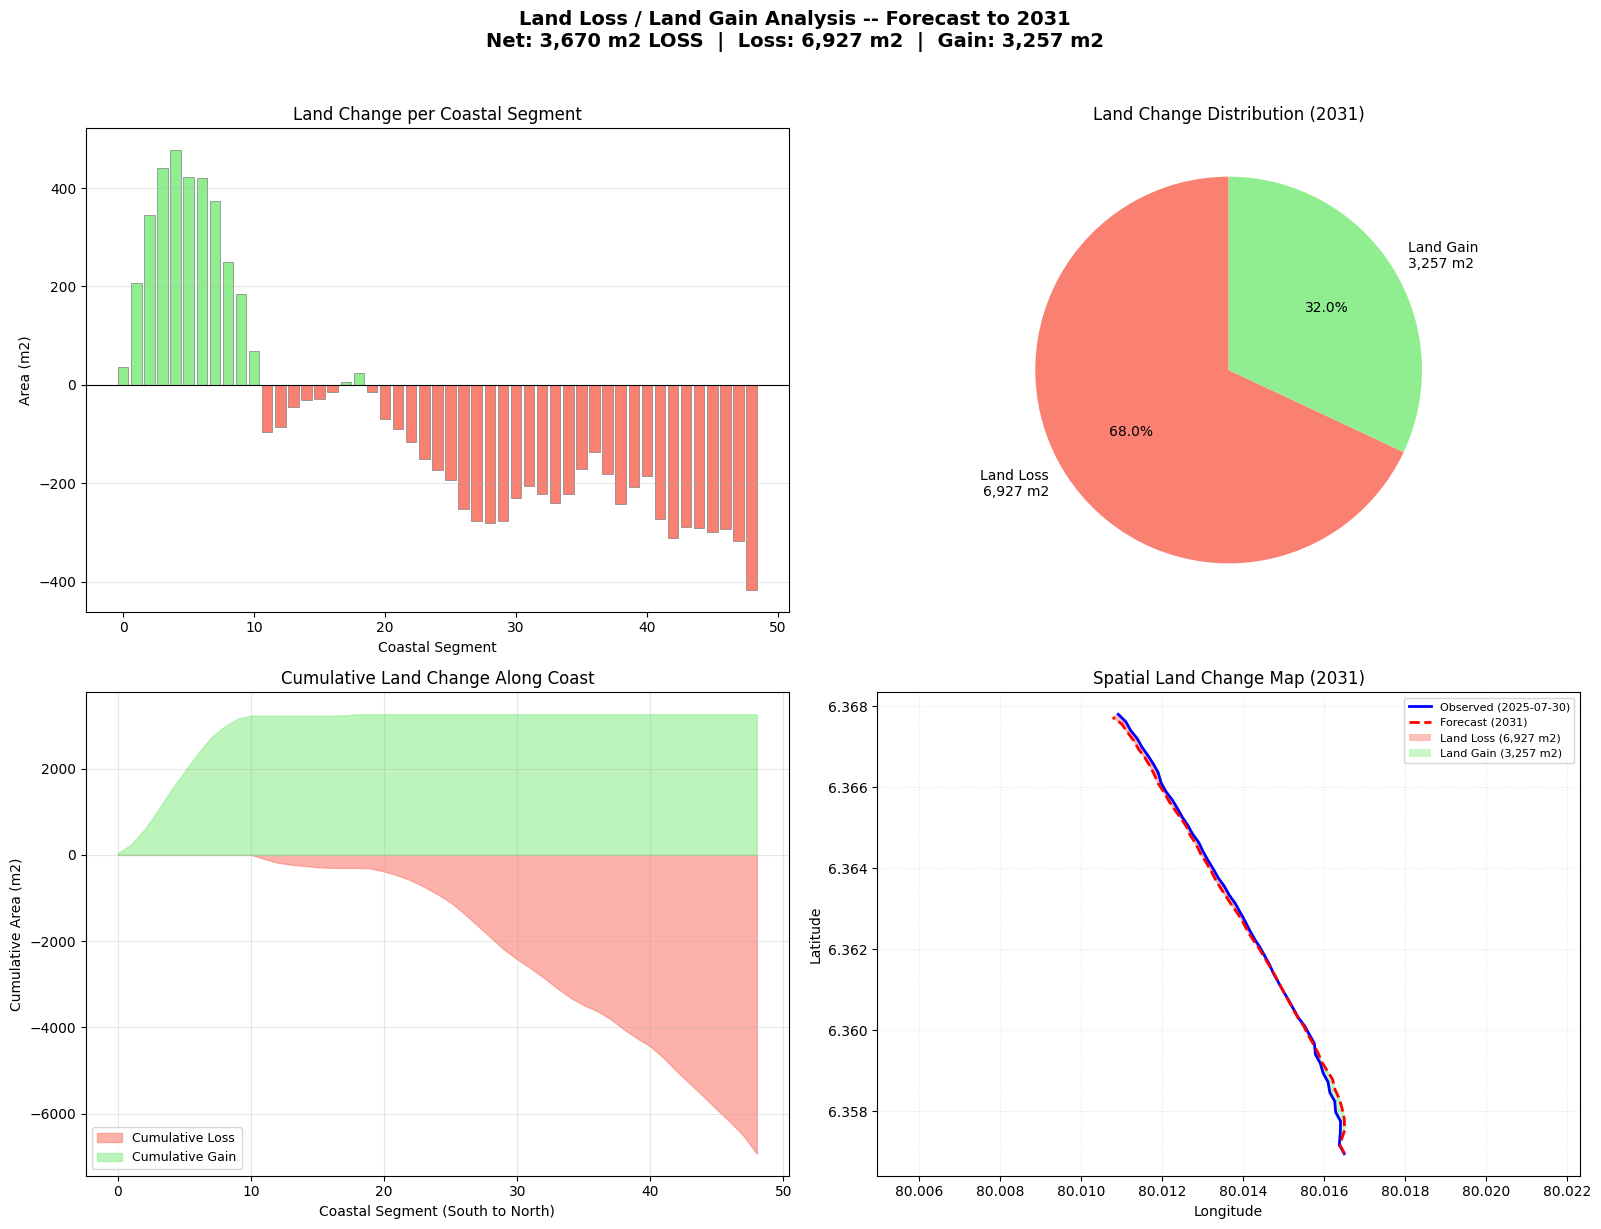

   Chart saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\land_change_2031.png
   Details saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\land_change_detail_2031.csv
   Summary saved: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\output\land_change_summary_2031.txt

   Land Change Analysis Complete!


In [18]:
# Run Land Loss / Land Gain Analysis
# When run via Papermill, TARGET_YEAR and MODEL_TYPE are injected as parameters
land_df = calculate_land_change(target_year=TARGET_YEAR, model_type=MODEL_TYPE)
